In [ ]:
import numpy as np
from math import cos, sin, radians
import copy
import sympy as sp
import numpy as np
import matplotlib.pyplot as plt
plt.style.use("seaborn-v0_8-whitegrid")
from collections import Counter
from IPython.display import display # for printing things in LaTex

In [234]:
# for plots
palette = {
    "invalid_overlap": "#264653",  # dark blue
    "jammed": "#2A9D8F",           # teal
    "semi-jammed": "#E9C46A",      # sand
    "free": "#F4A261",             # orange
}

In [55]:
# ------------------------------------------------------------
# 1. Define symbolic node coordinates (FULL NODE MODEL)
# ------------------------------------------------------------

# Unit 0 nodes
y0B, z0B = sp.symbols('y0B z0B', real=True)  # bottom
y0L, z0L = sp.symbols('y0L z0L', real=True)  # left
y0R, z0R = sp.symbols('y0R z0R', real=True)  # right
y0T, z0T = sp.symbols('y0T z0T', real=True)  # top

# Unit 1 nodes
y1B, z1B = sp.symbols('y1B z1B', real=True)  # bottom
y1L, z1L = sp.symbols('y1L z1L', real=True)  # left
y1R, z1R = sp.symbols('y1R z1R', real=True)  # right
y1T, z1T = sp.symbols('y1T z1T', real=True)  # top

# Node list IMPORTANT: pay attention to order
nodes = [
    sp.Matrix([y0B, z0B]),  # 0 = p0B
    sp.Matrix([y0L, z0L]),  # 1 = p0L
    sp.Matrix([y0R, z0R]),  # 2 = p0R
    sp.Matrix([y0T, z0T]),  # 3 = p0T
    sp.Matrix([y1B, z1B]),  # 4 = p1B
    sp.Matrix([y1L, z1L]),  # 5 = p1L
    sp.Matrix([y1R, z1R]),  # 6 = p1R
    sp.Matrix([y1T, z1T]),  # 7 = p1T
]

# TODO: plot nodes

# good to store this info; may use later
N = len(nodes)
dim = 2

print("total nodes:", N)
print("dimensions:", dim)

total nodes: 8
dimensions: 2


In [56]:
def get_nodes(conf):
    """
    Convert config dict → structured node dictionary.

    Returns:
    {
        "0": {"B": [y, z], "L": [y, z], "R": [y, z], "T": [y, z]},
        "1": {"B": [y, z], "L": [y, z], "R": [y, z], "T": [y, z]},
    }
    """
    nodes = {
        "0": {
            "B": np.array([float(conf[y0B]), float(conf[z0B])]),
            "L": np.array([float(conf[y0L]), float(conf[z0L])]),
            "R": np.array([float(conf[y0R]), float(conf[z0R])]),
            "T": np.array([float(conf[y0T]), float(conf[z0T])]),
        },
        "1": {
            "B": np.array([float(conf[y1B]), float(conf[z1B])]),
            "L": np.array([float(conf[y1L]), float(conf[z1L])]),
            "R": np.array([float(conf[y1R]), float(conf[z1R])]),
            "T": np.array([float(conf[y1T]), float(conf[z1T])]),
        }
    }
    return nodes

def get_nodes_flat(conf):
    return {
        "0B": np.array([float(conf[y0B]), float(conf[z0B])]),
        "0L": np.array([float(conf[y0L]), float(conf[z0L])]),
        "0R": np.array([float(conf[y0R]), float(conf[z0R])]),
        "0T": np.array([float(conf[y0T]), float(conf[z0T])]),
        "1B": np.array([float(conf[y1B]), float(conf[z1B])]),
        "1L": np.array([float(conf[y1L]), float(conf[z1L])]),
        "1R": np.array([float(conf[y1R]), float(conf[z1R])]),
        "1T": np.array([float(conf[y1T]), float(conf[z1T])]),
    }

def get_nodes_with_aliases(conf):
    nodes = get_nodes(conf)

    P0B = nodes["0"]["B"]
    P0L = nodes["0"]["L"]
    P0R = nodes["0"]["R"]
    P0T = nodes["0"]["T"]

    P1B = nodes["1"]["B"]
    P1L = nodes["1"]["L"]
    P1R = nodes["1"]["R"]
    P1T = nodes["1"]["T"]

    return nodes, P0B, P0L, P0R, P0T, P1B, P1L, P1R, P1T

In [101]:
# ------------------------------------------------------------
# Assumes your symbolic keys already exist in the notebook:
# y0B, z0B, y0L, z0L, ..., y1T, z1T
# ------------------------------------------------------------

# Example reference configuration
conf_1 = {
    y0B: 0,   z0B: 0,
    y0L: -8,  z0L: 10,
    y0R:  8,  z0R: 10,
    y0T: 0,   z0T: 20,

    y1B: 0,   z1B: 10,
    y1L: -8,  z1L: 20,
    y1R:  8,  z1R: 20,
    y1T: 0,   z1T: 30,
}

# ------------------------------------------------------------
# Helpers
# ------------------------------------------------------------

def pt(conf, yk, zk):
    """Return point as numpy array [y, z]."""
    return np.array([float(conf[yk]), float(conf[zk])], dtype=float)

def dist2(P, Q):
    d = P - Q
    return float(d @ d)

def orient(A, B, P):
    """
    Signed 2D area / cross product:
    positive if P is to one side of directed line A->B,
    negative if to the other side,
    zero if collinear.
    """
    return (B[0] - A[0]) * (P[1] - A[1]) - (B[1] - A[1]) * (P[0] - A[0])

def signed_segment_barrier(P, A, B, safe_sign=+1, outside_value=1e6):
    """
    Signed barrier for a point P relative to a finite segment A->B.

    Returns
    -------
    gap : float
        > 0 : safe
        = 0 : contact
        < 0 : crossed / violated

    info : dict
        debug info

    Logic
    -----
    1. Compute projection of P onto the line through A->B
    2. If the projection lies in the segment interior, use signed line distance
    3. If projection lies outside the segment, return a large positive value
       (meaning this segment is not the active local barrier for this point)

    safe_sign
    ---------
    Choose +1 or -1 so that the REFERENCE VALID configuration gives gap > 0.
    """
    AB = B - A
    AP = P - A
    denom = np.dot(AB, AB)

    if np.isclose(denom, 0.0):
        return outside_value, {
            "t_raw": 0.0,
            "projection_interior": False,
            "signed_line_distance": None,
            "orient": 0.0,
        }

    t_raw = np.dot(AP, AB) / denom
    projection_interior = (0.0 <= t_raw <= 1.0)

    s = orient(A, B, P)
    line_dist_signed = safe_sign * s / np.linalg.norm(AB)

    if projection_interior:
        gap = line_dist_signed
    else:
        gap = outside_value

    info = {
        "t_raw": float(t_raw),
        "projection_interior": projection_interior,
        "signed_line_distance": float(line_dist_signed),
        "orient": float(s),
    }
    return float(gap), info

def point_segment_contact_data(P, A, B):
    """
    Compute geometric relationship between point P and segment A->B.

    Parameters
    ----------
    P : np.array shape (2,)
        Point
    A : np.array shape (2,)
        Segment start
    B : np.array shape (2,)
        Segment end

    Returns
    -------
    data : dict
        {
            "t_raw": float,               # projection onto infinite line
            "t_clamped": float,           # projection clamped to [0,1]
            "closest_point": np.array,    # closest point on segment
            "distance": float,            # Euclidean distance point->segment
            "feature": str,               # "interior", "endpoint_A", "endpoint_B"
            "segment_vector": np.array,   # B - A
        }
    """
    AB = B - A
    AP = P - A
    denom = np.dot(AB, AB)

    if np.isclose(denom, 0.0):
        closest = A.copy()
        dist = np.linalg.norm(P - A)
        return {
            "t_raw": 0.0,
            "t_clamped": 0.0,
            "closest_point": closest,
            "distance": float(dist),
            "feature": "endpoint_A",
            "segment_vector": AB,
        }

    t_raw = np.dot(AP, AB) / denom
    t_clamped = np.clip(t_raw, 0.0, 1.0)
    closest = A + t_clamped * AB
    dist = np.linalg.norm(P - closest)

    if 0.0 < t_raw < 1.0:
        feature = "interior"
    elif t_raw <= 0.0:
        feature = "endpoint_A"
    else:
        feature = "endpoint_B"

    return {
        "t_raw": float(t_raw),
        "t_clamped": float(t_clamped),
        "closest_point": closest,
        "distance": float(dist),
        "feature": feature,
        "segment_vector": AB,
        "orientation": float(orient(A, B, P)),
    }

# ------------------------------------------------------------
# Equality constraints: valid RAMM configuration
# ------------------------------------------------------------

def get_reference_unit1_lengths(conf_ref):
    """
    Use the reference configuration to define the rigid geometry of unit 1.
    """
    B = pt(conf_ref, y1B, z1B)
    L = pt(conf_ref, y1L, z1L)
    R = pt(conf_ref, y1R, z1R)
    T = pt(conf_ref, y1T, z1T)

    return {
        "BL2": dist2(B, L),
        "BR2": dist2(B, R),
        "LT2": dist2(L, T),
        "RT2": dist2(R, T),
        # optional diagonals for extra validation
        "BT2": dist2(B, T),
        "LR2": dist2(L, R),
    }

unit1_ref = get_reference_unit1_lengths(conf_1)

def equality_residuals(conf, conf_ref=conf_1):
    """
    Residuals that should be ~0 if the configuration is valid.
    """
    B0 = pt(conf, y0B, z0B)
    L0 = pt(conf, y0L, z0L)
    R0 = pt(conf, y0R, z0R)
    T0 = pt(conf, y0T, z0T)

    B1 = pt(conf, y1B, z1B)
    L1 = pt(conf, y1L, z1L)
    R1 = pt(conf, y1R, z1R)
    T1 = pt(conf, y1T, z1T)

    B0_ref = pt(conf_ref, y0B, z0B)
    L0_ref = pt(conf_ref, y0L, z0L)
    R0_ref = pt(conf_ref, y0R, z0R)
    T0_ref = pt(conf_ref, y0T, z0T)

    # bottom unit fixed
    fixed_bottom = [
        B0[0] - B0_ref[0], B0[1] - B0_ref[1],
        L0[0] - L0_ref[0], L0[1] - L0_ref[1],
        R0[0] - R0_ref[0], R0[1] - R0_ref[1],
        T0[0] - T0_ref[0], T0[1] - T0_ref[1],
    ]

    # top unit rigid
    rigid_top = [
        dist2(B1, L1) - unit1_ref["BL2"],
        dist2(B1, R1) - unit1_ref["BR2"],
        dist2(L1, T1) - unit1_ref["LT2"],
        dist2(R1, T1) - unit1_ref["RT2"],
        # optional diagonals
        dist2(B1, T1) - unit1_ref["BT2"],
        dist2(L1, R1) - unit1_ref["LR2"],
    ]

    # 1B moves only vertically
    vertical_slider = [
        conf[y1B] - conf_ref[y1B]   # y1B should stay at 0 here
    ]

    return {
        "fixed_bottom": fixed_bottom,
        "rigid_top": rigid_top,
        "vertical_slider": vertical_slider,
    }

def satisfies_shape_constraints(conf, tol=1e-7):
    res = equality_residuals(conf)
    vals = res["fixed_bottom"] + res["rigid_top"] + res["vertical_slider"]
    return max(abs(v) for v in vals) < tol

# ------------------------------------------------------------
# Inequality constraints / contact gap functions
# ------------------------------------------------------------

def gap_functions(conf):
    nodes = get_nodes(conf)

    P0L = nodes["0"]["L"]
    P0R = nodes["0"]["R"]
    P0T = nodes["0"]["T"]

    P1B = nodes["1"]["B"]
    P1L = nodes["1"]["L"]
    P1R = nodes["1"]["R"]

    g = {}

    # --------------------------------------------------
    # Vertical ordering constraints (z direction)
    # --------------------------------------------------

    g["node_1B_must_stay_below_0T_z"] = float(conf[z0T] - conf[z1B])
    g["node_1L_must_stay_above_0L_z"] = float(conf[z1L] - conf[z0L])
    g["node_1R_must_stay_above_0R_z"] = float(conf[z1R] - conf[z0R])

    # --------------------------------------------------
    # Finite-segment signed barriers (lower contacts)
    # --------------------------------------------------

    # Choose safe_sign so conf_1 is positive
    g["seg_1L_1B_cannot_cross_0L_signed_barrier"], info_0L = signed_segment_barrier(
        P=P0L, A=P1L, B=P1B, safe_sign=-1
    )

    g["seg_1R_1B_cannot_cross_0R_signed_barrier"], info_0R = signed_segment_barrier(
        P=P0R, A=P1R, B=P1B, safe_sign=+1
    )

    # --------------------------------------------------
    # Horizontal ordering constraints around 0T (y direction)
    # --------------------------------------------------

    g["node_1L_must_stay_left_of_node_0T_y"] = float(conf[y0T] - conf[y1L])
    g["node_1R_must_stay_right_of_node_0T_y"] = float(conf[y1R] - conf[y0T])

    return g

def classify_contact_state(conf, contact_tol=1e-6):
    g = gap_functions(conf)

    one_sided_keys = [
        "node_1B_must_stay_below_0T_z",
        "node_1L_must_stay_above_0L_z",
        "node_1R_must_stay_above_0R_z",
        "seg_1L_1B_cannot_cross_0L_signed_barrier",
        "seg_1R_1B_cannot_cross_0R_signed_barrier",
        "node_1L_must_stay_left_of_node_0T_y",
        "node_1R_must_stay_right_of_node_0T_y",
    ]

    violated = [k for k in one_sided_keys if g[k] < -contact_tol]
    active   = [k for k in one_sided_keys if abs(g[k]) <= contact_tol]
    clear    = [k for k in one_sided_keys if g[k] > contact_tol]

    if violated:
        state = "invalid_overlap"
    elif active:
        state = "contacting"
    else:
        state = "free"

    return {
        "state": state,
        "violated": violated,
        "active": active,
        "clear": clear,
        "gaps": g,
    }

# ------------------------------------------------------------
# Convenient path through node-space:
# rigidly rotate unit 1 about 1B, then allow a vertical drop dz
# ------------------------------------------------------------

def transform_top_unit_from_reference(conf_ref, theta_deg=0.0, dz=0.0):
    """
    Creates a new full-node configuration by:
      - keeping unit 0 fixed
      - keeping unit 1 rigid
      - rotating unit 1 about node 1B by theta_deg
      - then shifting only 1B in z by dz, with the whole rigid unit following

    Positive theta = CCW in (y,z).
    """
    out = dict(conf_ref)

    B_ref = pt(conf_ref, y1B, z1B)
    L_ref = pt(conf_ref, y1L, z1L)
    R_ref = pt(conf_ref, y1R, z1R)
    T_ref = pt(conf_ref, y1T, z1T)

    th = radians(-theta_deg)
    Rm = np.array([
        [cos(th), -sin(th)],
        [sin(th),  cos(th)]
    ])

    # keep y1B fixed, allow z shift
    B_new = np.array([B_ref[0], B_ref[1] + dz])

    def xform(P_ref):
        rel = P_ref - B_ref
        return B_new + Rm @ rel

    L_new = xform(L_ref)
    R_new = xform(R_ref)
    T_new = xform(T_ref)

    out[y1B], out[z1B] = B_new[0], B_new[1]
    out[y1L], out[z1L] = L_new[0], L_new[1]
    out[y1R], out[z1R] = R_new[0], R_new[1]
    out[y1T], out[z1T] = T_new[0], T_new[1]

    return out

In [102]:
# metadata
def segment_contact_debug_info(conf):
    nodes = get_nodes(conf)

    P0L = nodes["0"]["L"]
    P0R = nodes["0"]["R"]
    P1L = nodes["1"]["L"]
    P1R = nodes["1"]["R"]
    P1B = nodes["1"]["B"]

    info = {
        "node_0L_vs_seg_1L_1B": point_segment_contact_data(P0L, P1L, P1B),
        "node_0R_vs_seg_1R_1B": point_segment_contact_data(P0R, P1R, P1B),
    }

    return info

def debug_lower_segment_barriers(conf):
    nodes = get_nodes(conf)

    P0L = nodes["0"]["L"]
    P0R = nodes["0"]["R"]
    P1L = nodes["1"]["L"]
    P1R = nodes["1"]["R"]
    P1B = nodes["1"]["B"]

    gap_L, info_L = signed_segment_barrier(P0L, P1L, P1B, safe_sign=-1)
    gap_R, info_R = signed_segment_barrier(P0R, P1R, P1B, safe_sign=+1)

    print("\nLeft barrier: seg_1L_1B vs 0L")
    print(f"  gap: {gap_L:.6f}")
    print(f"  t_raw: {info_L['t_raw']:.6f}")
    print(f"  projection_interior: {info_L['projection_interior']}")
    print(f"  signed_line_distance: {info_L['signed_line_distance']}")

    print("\nRight barrier: seg_1R_1B vs 0R")
    print(f"  gap: {gap_R:.6f}")
    print(f"  t_raw: {info_R['t_raw']:.6f}")
    print(f"  projection_interior: {info_R['projection_interior']}")
    print(f"  signed_line_distance: {info_R['signed_line_distance']}")

In [103]:
# pretty printers
def print_point_segment_contact_data(name, data):
    cp = data["closest_point"]
    print(f"\n{name}")
    print(f"  feature       : {data['feature']}")
    print(f"  t_raw         : {data['t_raw']:.6f}")
    print(f"  t_clamped     : {data['t_clamped']:.6f}")
    print(f"  closest_point : (y={cp[0]:.6f}, z={cp[1]:.6f})")
    print(f"  distance      : {data['distance']:.6f}")

def pretty_print_nodes_and_gaps(conf, contact_tol=1e-6):
    nodes = get_nodes(conf)
    gaps = gap_functions(conf)
    result = classify_contact_state(conf, contact_tol)

    def fmt(pt):
        return f"(y={pt[0]:6.2f}, z={pt[1]:6.2f})"

    print("\n========================================================")
    print("                    NODE POSITIONS")
    print("========================================================")

    for unit in ["0", "1"]:
        print(f"\n--- Unit {unit} ---")
        print(f"        T: {fmt(nodes[unit]['T'])}")
        print(f"        L: {fmt(nodes[unit]['L'])}")
        print(f"        R: {fmt(nodes[unit]['R'])}")
        print(f"        B: {fmt(nodes[unit]['B'])}")

    print("\n========================================================")
    print("                    CONTACT STATE")
    print("========================================================")
    print(f"State: {result['state'].upper()}")

    print("\n========================================================")
    print("                      GAP VALUES")
    print("========================================================")

    for k, v in sorted(gaps.items()):
        # classify each gap visually
        if v < -contact_tol:
            status = "❌ VIOLATED"
        elif abs(v) <= contact_tol:
            status = "⚠️ CONTACT"
        else:
            status = "✅ CLEAR"

        print(f"{k:45s} {v: .6f}   {status}")

    # Optional: explicitly list key constraints
    if result["violated"]:
        print("\n❌ Violated constraints:")
        for k in result["violated"]:
            print(f"   - {k}")

    if result["active"]:
        print("\n⚠️ Active (contact) constraints:")
        for k in result["active"]:
            print(f"   - {k}")

In [104]:
pretty_print_nodes_and_gaps(conf_1)


                    NODE POSITIONS

--- Unit 0 ---
        T: (y=  0.00, z= 20.00)
        L: (y= -8.00, z= 10.00)
        R: (y=  8.00, z= 10.00)
        B: (y=  0.00, z=  0.00)

--- Unit 1 ---
        T: (y=  0.00, z= 30.00)
        L: (y= -8.00, z= 20.00)
        R: (y=  8.00, z= 20.00)
        B: (y=  0.00, z= 10.00)

                    CONTACT STATE
State: FREE

                      GAP VALUES
node_1B_must_stay_below_0T_z                   10.000000   ✅ CLEAR
node_1L_must_stay_above_0L_z                   10.000000   ✅ CLEAR
node_1L_must_stay_left_of_node_0T_y            8.000000   ✅ CLEAR
node_1R_must_stay_above_0R_z                   10.000000   ✅ CLEAR
node_1R_must_stay_right_of_node_0T_y           8.000000   ✅ CLEAR
seg_1L_1B_cannot_cross_0L_signed_barrier       6.246950   ✅ CLEAR
seg_1R_1B_cannot_cross_0R_signed_barrier       6.246950   ✅ CLEAR


In [105]:
# Plot geometry
def get_node(geom, y_key, z_key):
    return (geom[y_key], geom[z_key])

def plot_unit(ax, geom, unit_keys, unit_name="0", show_labels=True):
    B = get_node(geom, unit_keys["B"][0], unit_keys["B"][1])
    L = get_node(geom, unit_keys["L"][0], unit_keys["L"][1])
    T = get_node(geom, unit_keys["T"][0], unit_keys["T"][1])
    R = get_node(geom, unit_keys["R"][0], unit_keys["R"][1])

    edges = [(B, L), (L, T), (T, R), (R, B)]
    for p1, p2 in edges:
        ax.plot([p1[0], p2[0]], [p1[1], p2[1]], linewidth=2)

    nodes = {"B": B, "L": L, "R": R, "T": T}
    for name, (y, z) in nodes.items():
        ax.plot(y, z, "o", markersize=8)
        if show_labels:
            ax.text(y + 0.4, z + 0.4, f"{unit_name}{name}", fontsize=10)

def plot_geometry(geom, title="RAMM Geometry"):
    fig, ax = plt.subplots(figsize=(6, 8))

    unit0_keys = {
        "B": (y0B, z0B),
        "L": (y0L, z0L),
        "R": (y0R, z0R),
        "T": (y0T, z0T),
    }

    unit1_keys = {
        "B": (y1B, z1B),
        "L": (y1L, z1L),
        "R": (y1R, z1R),
        "T": (y1T, z1T),
    }

    plot_unit(ax, geom, unit0_keys, unit_name="0")
    plot_unit(ax, geom, unit1_keys, unit_name="1")

    ax.set_xlabel("y")
    ax.set_ylabel("z")
    ax.set_title(title)
    ax.set_aspect("equal")
    ax.grid(True)
    plt.show()

In [254]:
# ------------------------------------------------------------
# Testing
# ------------------------------------------------------------

# rotate
#test_conf = transform_top_unit_from_reference(conf_1, theta_deg=38, dz=-1.8)

# move down
test_conf = transform_top_unit_from_reference(conf_1, theta_deg=0, dz=-10) #-> semi-jammed at -10!

In [255]:
debug_lower_segment_barriers(test_conf)


Left barrier: seg_1L_1B vs 0L
  gap: -0.000000
  t_raw: 0.000000
  projection_interior: True
  signed_line_distance: -0.0

Right barrier: seg_1R_1B vs 0R
  gap: 0.000000
  t_raw: 0.000000
  projection_interior: True
  signed_line_distance: 0.0


In [256]:
info = segment_contact_debug_info(test_conf)
print_point_segment_contact_data("node_0L_vs_seg_1L_1B", info["node_0L_vs_seg_1L_1B"])
print_point_segment_contact_data("node_0R_vs_seg_1R_1B", info["node_0R_vs_seg_1R_1B"])


node_0L_vs_seg_1L_1B
  feature       : endpoint_A
  t_raw         : 0.000000
  t_clamped     : 0.000000
  closest_point : (y=-8.000000, z=10.000000)
  distance      : 0.000000

node_0R_vs_seg_1R_1B
  feature       : endpoint_A
  t_raw         : 0.000000
  t_clamped     : 0.000000
  closest_point : (y=8.000000, z=10.000000)
  distance      : 0.000000


Nodes satisfy diamond shape constraints?: True

                    NODE POSITIONS

--- Unit 0 ---
        T: (y=  0.00, z= 20.00)
        L: (y= -8.00, z= 10.00)
        R: (y=  8.00, z= 10.00)
        B: (y=  0.00, z=  0.00)

--- Unit 1 ---
        T: (y=  0.00, z= 20.00)
        L: (y= -8.00, z= 10.00)
        R: (y=  8.00, z= 10.00)
        B: (y=  0.00, z=  0.00)

                    CONTACT STATE
State: CONTACTING

                      GAP VALUES
node_1B_must_stay_below_0T_z                   20.000000   ✅ CLEAR
node_1L_must_stay_above_0L_z                   0.000000   ⚠️ CONTACT
node_1L_must_stay_left_of_node_0T_y            8.000000   ✅ CLEAR
node_1R_must_stay_above_0R_z                   0.000000   ⚠️ CONTACT
node_1R_must_stay_right_of_node_0T_y           8.000000   ✅ CLEAR
seg_1L_1B_cannot_cross_0L_signed_barrier      -0.000000   ⚠️ CONTACT
seg_1R_1B_cannot_cross_0R_signed_barrier       0.000000   ⚠️ CONTACT

⚠️ Active (contact) constraints:
   - node_1L_must_stay_above_0L_z

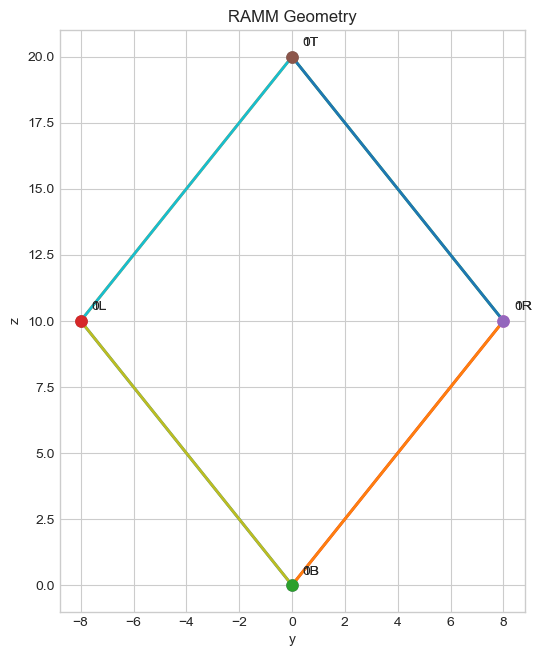

In [257]:

print("Nodes satisfy diamond shape constraints?:", satisfies_shape_constraints(test_conf))
pretty_print_nodes_and_gaps(test_conf)
plot_geometry(test_conf)

In [258]:
# recover theta and z for small perturbation test
def signed_angle_deg(v_ref, v_cur):
    """
    Signed angle from v_ref to v_cur in degrees.
    Positive = CCW in standard math convention.
    """
    cross = v_ref[0] * v_cur[1] - v_ref[1] * v_cur[0]
    dot = v_ref[0] * v_cur[0] + v_ref[1] * v_cur[1]
    return np.degrees(np.arctan2(cross, dot))


def extract_theta_dz_from_conf(conf, conf_ref):
    """
    Recover the user-facing (theta_deg, dz) from a configuration
    generated by transform_top_unit_from_reference(...).

    Assumes your transform uses:
        th = radians(-theta_deg)

    so we flip the sign back before returning theta_deg.
    """
    nodes_ref = get_nodes(conf_ref)
    nodes_cur = get_nodes(conf)

    B_ref = nodes_ref["1"]["B"]
    T_ref = nodes_ref["1"]["T"]

    B_cur = nodes_cur["1"]["B"]
    T_cur = nodes_cur["1"]["T"]

    v_ref = T_ref - B_ref
    v_cur = T_cur - B_cur

    # standard math signed angle
    theta_math_deg = signed_angle_deg(v_ref, v_cur)

    # if your transform uses th = radians(-theta_deg),
    # then user-facing theta is the negative of the math angle
    theta_deg = -theta_math_deg

    dz = float(B_cur[1] - B_ref[1])

    return float(theta_deg), dz

In [259]:
# small perturbation test
def generate_local_perturbations(theta_deg, dz, dtheta=0.5, ddz=0.1):
    """
    Returns a list of local perturbations around (theta_deg, dz).

    We exclude (0,0) because that's the current state.
    """
    perturbations = [
        (+dtheta, 0.0),
        (-dtheta, 0.0),
        (0.0, +ddz),
        (0.0, -ddz),
        (+dtheta, +ddz),
        (+dtheta, -ddz),
        (-dtheta, +ddz),
        (-dtheta, -ddz),
    ]
    return perturbations

In [260]:
def local_perturbation_test(
    conf,
    conf_ref,
    contact_tol=1e-6,
    dtheta=0.5,
    ddz=0.1,
    verbose=False
):
    """
    Test whether any small admissible perturbation survives.

    Returns
    -------
    result : dict
        {
            "base_state": ...,
            "theta_deg": ...,
            "dz": ...,
            "survivors": [...],
            "blocked": [...],
            "n_survivors": int,
            "n_blocked": int,
        }
    """
    base_class = classify_contact_state(conf, contact_tol)
    base_state = base_class["state"]

    theta_deg, dz = extract_theta_dz_from_conf(conf, conf_ref)

    survivors = []
    blocked = []

    for dth, ddz_local in generate_local_perturbations(theta_deg, dz, dtheta, ddz):
        th_new = theta_deg + dth
        dz_new = dz + ddz_local

        conf_new = transform_top_unit_from_reference(conf_ref, theta_deg=th_new, dz=dz_new)
        state_new = classify_contact_state(conf_new, contact_tol)["state"]

        entry = {
            "dtheta": dth,
            "ddz": ddz_local,
            "theta_new": th_new,
            "dz_new": dz_new,
            "state": state_new,
            "conf": conf_new,
        }

        if state_new != "invalid_overlap":
            survivors.append(entry)
        else:
            blocked.append(entry)

    if verbose:
        print("\nLocal perturbation test")
        print(f"Base state : {base_state}")
        print(f"Base theta : {theta_deg:.6f} deg")
        print(f"Base dz    : {dz:.6f}")
        print(f"Survivors  : {len(survivors)}")
        print(f"Blocked    : {len(blocked)}")

    return {
        "base_state": base_state,
        "theta_deg": theta_deg,
        "dz": dz,
        "survivors": survivors,
        "blocked": blocked,
        "n_survivors": len(survivors),
        "n_blocked": len(blocked),
    }

In [ ]:
def classify_jamming_state(
    conf,
    conf_ref,
    contact_tol=1e-6,
    dtheta=0.25,
    ddz=0.05,
):
    base = classify_contact_state(conf, contact_tol)
    base_state = base["state"]

    if base_state == "free":
        return {
            "state": "free",
            "base_contact_state": base_state,
            "n_contact_survivors": None,
            "n_free_survivors": None,
            "n_blocked": None,
            "contact_survivors": [],
            "free_survivors": [],
            "blocked": [],
            "theta_deg": None,
            "dz": None,
        }

    if base_state == "invalid_overlap":
        return {
            "state": "invalid_overlap",
            "base_contact_state": base_state,
            "n_contact_survivors": None,
            "n_free_survivors": None,
            "n_blocked": None,
            "contact_survivors": [],
            "free_survivors": [],
            "blocked": [],
            "theta_deg": None,
            "dz": None,
        }

    # only refine "contacting"
    theta_deg, dz = extract_theta_dz_from_conf(conf, conf_ref)

    perturbations = [
        (+dtheta, 0.0),
        (-dtheta, 0.0),
        (0.0, +ddz),
        (0.0, -ddz),
        (+dtheta, +ddz),
        (+dtheta, -ddz),
        (-dtheta, +ddz),
        (-dtheta, -ddz),
    ]

    contact_survivors = []
    free_survivors = []
    blocked = []

    for dth, ddz_local in perturbations:
        th_new = theta_deg + dth
        dz_new = dz + ddz_local

        conf_new = transform_top_unit_from_reference(
            conf_ref,
            theta_deg=th_new,
            dz=dz_new,
        )

        new_state = classify_contact_state(conf_new, contact_tol)["state"]

        entry = {
            "dtheta": dth,
            "ddz": ddz_local,
            "theta_new": th_new,
            "dz_new": dz_new,
            "state": new_state,
            "conf": conf_new,
        }

        if new_state == "contacting":
            contact_survivors.append(entry)
        elif new_state == "free":
            free_survivors.append(entry)
        else:
            blocked.append(entry)

    # refined classification
    if len(contact_survivors) > 0:
        refined_state = "semi-jammed"
    elif len(free_survivors) > 0:
        refined_state = "contact_escape" # you're in contact, but only allowable move is to leave contact
    else:
        refined_state = "jammed"

    return {
        "state": refined_state,
        "base_contact_state": base_state,
        "n_contact_survivors": len(contact_survivors),
        "n_free_survivors": len(free_survivors),
        "n_blocked": len(blocked),
        "contact_survivors": contact_survivors,
        "free_survivors": free_survivors,
        "blocked": blocked,
        "theta_deg": theta_deg,
        "dz": dz,
    }

In [274]:
def pretty_print_jamming_state(
    conf,
    conf_ref,
    contact_tol=1e-6,
    dtheta=0.25,
    ddz=0.05,
):
    result = classify_jamming_state(
        conf=conf,
        conf_ref=conf_ref,
        contact_tol=contact_tol,
        dtheta=dtheta,
        ddz=ddz,
    )

    print("\n========================================================")
    print("                  JAMMING CLASSIFICATION")
    print("========================================================")
    print(f"Refined state          : {result['state'].upper()}")
    print(f"Base contact state     : {result['base_contact_state'].upper()}")

    if result["theta_deg"] is not None:
        print(f"Recovered theta_deg    : {result['theta_deg']:.6f}")
        print(f"Recovered dz           : {result['dz']:.6f}")
        print(f"Contact survivors      : {result['n_contact_survivors']}")
        print(f"Free survivors         : {result['n_free_survivors']}")
        print(f"Blocked perturbations  : {result['n_blocked']}")

    if result["contact_survivors"]:
        print("\n✅ Contact survivors (stay in contact):")
        for s in result["contact_survivors"]:
            print(
                f"   dtheta={s['dtheta']: .3f}, ddz={s['ddz']: .3f}  "
                f"-> theta={s['theta_new']: .3f}, dz={s['dz_new']: .3f}  "
                f"[{s['state']}]"
            )

    if result["free_survivors"]:
        print("\n🟡 Free survivors (escape contact):")
        for s in result["free_survivors"]:
            print(
                f"   dtheta={s['dtheta']: .3f}, ddz={s['ddz']: .3f}  "
                f"-> theta={s['theta_new']: .3f}, dz={s['dz_new']: .3f}  "
                f"[{s['state']}]"
            )

    if result["blocked"]:
        print("\n❌ Blocked perturbations:")
        for b in result["blocked"]:
            print(
                f"   dtheta={b['dtheta']: .3f}, ddz={b['ddz']: .3f}  "
                f"-> theta={b['theta_new']: .3f}, dz={b['dz_new']: .3f}  "
                f"[{b['state']}]"
            )

In [263]:
pretty_print_jamming_state(
    conf=test_conf,
    conf_ref=conf_1,
    # TODO: make these smaller if for more tests
    dtheta=0.25,
    ddz=0.05
)
#plot_geometry(test_conf)


                  JAMMING CLASSIFICATION
Refined state       : SEMI-JAMMED
Base contact state  : CONTACTING
Recovered theta_deg : -0.000000
Recovered dz        : -10.000000
Surviving motions   : 1
Blocked motions     : 7

✅ Surviving perturbations:
   dtheta= 0.000, ddz= 0.050  -> theta= 0.000, dz=-9.950  [free]

❌ Blocked perturbations:
   dtheta= 0.250, ddz= 0.000  -> theta= 0.250, dz=-10.000  [invalid_overlap]
   dtheta=-0.250, ddz= 0.000  -> theta=-0.250, dz=-10.000  [invalid_overlap]
   dtheta= 0.000, ddz=-0.050  -> theta= 0.000, dz=-10.050  [invalid_overlap]
   dtheta= 0.250, ddz= 0.050  -> theta= 0.250, dz=-9.950  [invalid_overlap]
   dtheta= 0.250, ddz=-0.050  -> theta= 0.250, dz=-10.050  [invalid_overlap]
   dtheta=-0.250, ddz= 0.050  -> theta=-0.250, dz=-9.950  [invalid_overlap]
   dtheta=-0.250, ddz=-0.050  -> theta=-0.250, dz=-10.050  [invalid_overlap]


In [ ]:
# --------------------------------------------
# CONFIGURATION (SET THIS ONCE)
# --------------------------------------------
REFERENCE_CONF = conf_1  # your base configuration

# --------------------------------------------
# JAMMING CLASSIFIER (single-config interface)
# --------------------------------------------

def signed_angle_deg(v_ref, v_cur):
    cross = v_ref[0] * v_cur[1] - v_ref[1] * v_cur[0]
    dot = v_ref[0] * v_cur[0] + v_ref[1] * v_cur[1]
    return np.degrees(np.arctan2(cross, dot))


def extract_theta_dz_from_conf(conf, conf_ref=REFERENCE_CONF):
    nodes_ref = get_nodes(conf_ref)
    nodes_cur = get_nodes(conf)

    B_ref = nodes_ref["1"]["B"]
    T_ref = nodes_ref["1"]["T"]
    B_cur = nodes_cur["1"]["B"]
    T_cur = nodes_cur["1"]["T"]

    v_ref = T_ref - B_ref
    v_cur = T_cur - B_cur

    theta_math = signed_angle_deg(v_ref, v_cur)

    # your convention
    theta_deg = -theta_math
    dz = float(B_cur[1] - B_ref[1])

    return theta_deg, dz

# --------------------------------------------
# SWEEP FUNCTION
# --------------------------------------------

def sweep_workspace(conf_ref, theta_vals, dz_vals, contact_tol=1e-6):
    results = []

    for theta in theta_vals:
        for dz in dz_vals:
            conf = transform_top_unit_from_reference(
                conf_ref,
                theta_deg=theta,
                dz=dz
            )

            gaps = gap_functions(conf)
            min_gap = min(gaps.values())

            contact_state = classify_contact_state(conf, contact_tol)["state"]
            jam_result = classify_jamming_state(
                conf=conf,
                conf_ref=conf_ref,
                contact_tol=contact_tol
            )

            results.append({
                "theta": theta,
                "dz": dz,
                "contact_state": contact_state,
                "jam_state": jam_result["state"],
                "min_gap": min_gap,
                "jam_result": jam_result,
            })

    return results


# --------------------------------------------
# PLOTTING HELPERS
# --------------------------------------------

def state_to_int(s):
    return {
        "invalid_overlap": 0,
        "jammed": 1,
        "semi-jammed": 2,
        "free": 3
    }[s]

In [277]:
def state_to_color(state):
    return {
        "invalid_overlap": "#264653",  # dark blue
        "jammed": "#2A9D8F",           # teal
        "semi-jammed": "#E9C46A",      # sand
        "contact_escape": "#F4A261",   # orange
        "free": "#E76F51",             # coral
    }[state]

def plot_workspace_2d_map(results):
    theta = np.array([r["theta"] for r in results])
    dz    = np.array([r["dz"] for r in results])
    colors = [state_to_color(r["jam_state"]) for r in results]

    plt.figure(figsize=(8,6))
    plt.scatter(theta, dz, c=colors, s=10)

    plt.xlabel("theta_deg")
    plt.ylabel("dz")
    plt.title("Workspace State Map")
    plt.grid(True)

    legend_colors = {
        "invalid_overlap": "#264653",
        "jammed": "#2A9D8F",
        "semi-jammed": "#E9C46A",
        "contact_escape": "#F4A261",
        "free": "#E76F51",
    }

    for label, color in legend_colors.items():
        plt.scatter([], [], c=color, label=label)

    plt.legend(loc="center left", bbox_to_anchor=(1, 0.5))
    plt.tight_layout() # so it doesnt get cut off
    plt.show()

def plot_workspace_3d_landscape(results):
    theta = np.array([r["theta"] for r in results])
    dz    = np.array([r["dz"] for r in results])
    z     = np.array([r["min_gap"] for r in results])
    colors = [state_to_color(r["jam_state"]) for r in results]

    fig = plt.figure(figsize=(10,7))
    ax = fig.add_subplot(111, projection='3d')

    ax.scatter(theta, dz, z, c=colors, s=8)

    ax.set_xlabel("theta_deg")
    ax.set_ylabel("dz")
    ax.set_zlabel("min gap")
    ax.set_title("Barrier Landscape")

    plt.show()

def plot_workspace_3d_active_constraints(results):
    theta = np.array([r["theta"] for r in results])  # FIXED
    dz    = np.array([r["dz"] for r in results])
    zval  = np.array([r["n_active"] for r in results])
    colors = [state_to_color(r["jam_state"]) for r in results]

    fig = plt.figure(figsize=(10, 7))
    ax = fig.add_subplot(111, projection="3d")

    ax.scatter(theta, dz, zval, c=colors, s=10)

    ax.set_xlabel("theta_deg")
    ax.set_ylabel("dz")
    ax.set_zlabel("number of active constraints")
    ax.set_title("RAMM Configuration Space: Active Contacts")

    plt.show()

In [ ]:
# TODO: change these if its running slow
theta_vals = np.linspace(-45, 45, 200) # 200 vals of theta going from -45 -> 45
dz_vals    = np.linspace(2, -12, 100) # 200 vals of dz going from 2 -> -12
# only shows intermediate states if it hits it exactly
# even with 2x values, still only shows two states
results = sweep_workspace(REFERENCE_CONF, theta_vals, dz_vals)

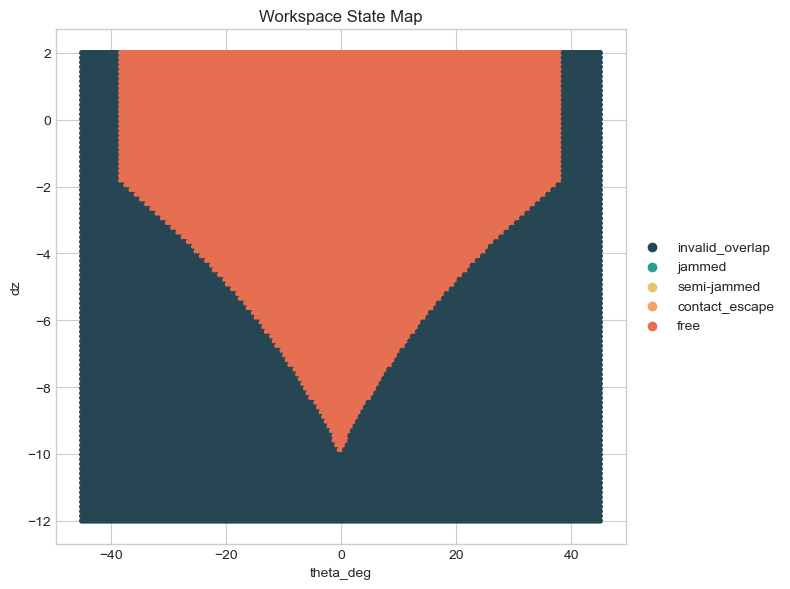

In [355]:
plot_workspace_2d_map(results)

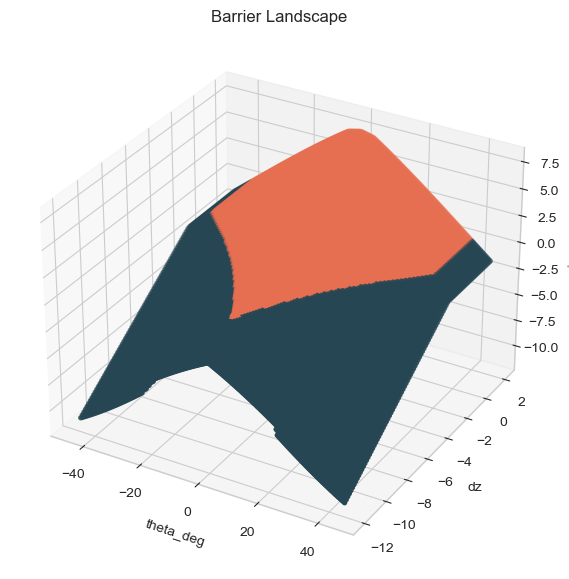

In [356]:
plot_workspace_3d_landscape(results)

In [304]:
# check random point
r = results[1000]
print(r)

{'theta': -40.47738693467337, 'dz': -12.0, 'contact_state': 'invalid_overlap', 'jam_state': 'invalid_overlap', 'min_gap': -10.277311656088617, 'jam_result': {'state': 'invalid_overlap', 'base_contact_state': 'invalid_overlap', 'n_contact_survivors': None, 'n_free_survivors': None, 'n_blocked': None, 'contact_survivors': [], 'free_survivors': [], 'blocked': [], 'theta_deg': None, 'dz': None}}



                    NODE POSITIONS

--- Unit 0 ---
        T: (y=  0.00, z= 20.00)
        L: (y= -8.00, z= 10.00)
        R: (y=  8.00, z= 10.00)
        B: (y=  0.00, z=  0.00)

--- Unit 1 ---
        T: (y=-12.98, z= 13.21)
        L: (y=-12.58, z=  0.41)
        R: (y= -0.41, z= 10.80)
        B: (y=  0.00, z= -2.00)

                    CONTACT STATE
State: INVALID_OVERLAP

                      GAP VALUES
node_1B_must_stay_below_0T_z                   22.000000   ✅ CLEAR
node_1L_must_stay_above_0L_z                  -9.586561   ❌ VIOLATED
node_1L_must_stay_left_of_node_0T_y            12.576777   ✅ CLEAR
node_1R_must_stay_above_0R_z                   0.799805   ✅ CLEAR
node_1R_must_stay_right_of_node_0T_y          -0.406181   ❌ VIOLATED
seg_1L_1B_cannot_cross_0L_signed_barrier      -10.277312   ❌ VIOLATED
seg_1R_1B_cannot_cross_0R_signed_barrier       8.376584   ✅ CLEAR

❌ Violated constraints:
   - node_1L_must_stay_above_0L_z
   - seg_1L_1B_cannot_cross_0L_signed_barrier
   - 

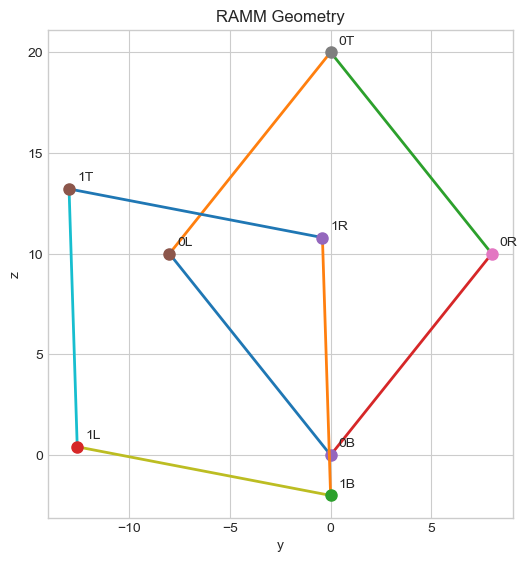

In [305]:
# more random point checking (make sure classification matches geometry)
conf = transform_top_unit_from_reference(
    conf_1,
    theta_deg=r["theta"],
    dz=r["dz"]
)

pretty_print_nodes_and_gaps(conf)
pretty_print_jamming_state(conf, conf_1)
plot_geometry(conf)

In [344]:
def contact_function(conf):
    gaps = gap_functions(conf)
    key = min(gaps, key=gaps.get)
    return float(gaps[key]), key


def evaluate_slice_point(conf_ref, theta_deg, dz, contact_tol=1e-6):
    conf = transform_top_unit_from_reference(conf_ref, theta_deg=theta_deg, dz=dz)
    contact_result = classify_contact_state(conf, contact_tol=contact_tol)

    contact_value, contact_key = contact_function(conf)

    return {
        "conf": conf,
        "contact_state": contact_result["state"],
        "contact_value": contact_value,
        "contact_key": contact_key,
    }

In [345]:
# scan over fixed theta
def scan_dz_slice(conf_ref, theta_deg, dz_vals, contact_tol=1e-6):
    records = []

    for dz in dz_vals:
        out = evaluate_slice_point(conf_ref, theta_deg, dz, contact_tol=contact_tol)
        records.append({
            "theta_deg": theta_deg,
            "dz": float(dz),
            "contact_state": out["contact_state"],
            "min_gap_key": out["min_gap_key"],
            "min_gap_val": out["min_gap_val"],
        })

    return records

In [346]:
def find_transition_intervals(slice_records):
    """
    Find intervals where the contact state changes or min_gap changes sign.
    """
    intervals = []

    for a, b in zip(slice_records[:-1], slice_records[1:]):
        state_changed = (a["contact_state"] != b["contact_state"])
        sign_changed = (a["min_gap_val"] * b["min_gap_val"] < 0)

        if state_changed or sign_changed:
            intervals.append((a, b))

    return intervals

In [347]:
def refine_contact_zero_bisection(
    conf_ref,
    theta_deg,
    dz_lo,
    dz_hi,
    contact_tol=1e-6,
    dz_tol=1e-5,
    max_iter=60,
):
    out_lo = evaluate_slice_point(conf_ref, theta_deg, dz_lo, contact_tol)
    out_hi = evaluate_slice_point(conf_ref, theta_deg, dz_hi, contact_tol)

    g_lo = out_lo["contact_value"]
    g_hi = out_hi["contact_value"]

    if abs(g_lo) <= contact_tol:
        return {
            "theta_deg": theta_deg,
            "candidate_dz": dz_lo,
            "candidate_conf": out_lo["conf"],
            "candidate_contact_value": g_lo,
            "contact_key": out_lo["contact_key"],
            "left_state": out_lo["contact_state"],
            "right_state": out_hi["contact_state"],
        }

    if abs(g_hi) <= contact_tol:
        return {
            "theta_deg": theta_deg,
            "candidate_dz": dz_hi,
            "candidate_conf": out_hi["conf"],
            "candidate_contact_value": g_hi,
            "contact_key": out_hi["contact_key"],
            "left_state": out_lo["contact_state"],
            "right_state": out_hi["contact_state"],
        }

    if g_lo * g_hi > 0:
        return None

    for _ in range(max_iter):
        if abs(dz_hi - dz_lo) < dz_tol:
            break

        dz_mid = 0.5 * (dz_lo + dz_hi)
        out_mid = evaluate_slice_point(conf_ref, theta_deg, dz_mid, contact_tol)
        g_mid = out_mid["contact_value"]

        if abs(g_mid) <= contact_tol:
            return {
                "theta_deg": theta_deg,
                "candidate_dz": dz_mid,
                "candidate_conf": out_mid["conf"],
                "candidate_contact_value": g_mid,
                "contact_key": out_mid["contact_key"],
                "left_state": out_lo["contact_state"],
                "right_state": out_hi["contact_state"],
            }

        if g_lo * g_mid < 0:
            dz_hi = dz_mid
            out_hi = out_mid
            g_hi = g_mid
        else:
            dz_lo = dz_mid
            out_lo = out_mid
            g_lo = g_mid

    dz_star = 0.5 * (dz_lo + dz_hi)
    out_star = evaluate_slice_point(conf_ref, theta_deg, dz_star, contact_tol)

    return {
        "theta_deg": theta_deg,
        "candidate_dz": dz_star,
        "candidate_conf": out_star["conf"],
        "candidate_contact_value": out_star["contact_value"],
        "contact_key": out_star["contact_key"],
        "left_state": out_lo["contact_state"],
        "right_state": out_hi["contact_state"],
    }

In [348]:
def find_first_contact_dz_for_theta(
    conf_ref,
    theta_deg,
    dz_min=-12,
    dz_max=2,
    n_scan=500,
    contact_tol=1e-6,
    dz_tol=1e-5,
):
    dz_vals = np.linspace(dz_min, dz_max, n_scan)
    records = [
        {
            "dz": dz,
            **evaluate_slice_point(conf_ref, theta_deg, dz, contact_tol)
        }
        for dz in dz_vals
    ]

    for a, b in zip(records[:-1], records[1:]):
        g_a = a["contact_value"]
        g_b = b["contact_value"]

        # detect ANY crossing of zero
        if abs(g_a) <= contact_tol:
            return {
                "theta_deg": theta_deg,
                "candidate_dz": a["dz"],
                "candidate_conf": a["conf"],
                "candidate_contact_value": g_a,
                "contact_key": a["contact_key"],
                "left_state": a["contact_state"],
                "right_state": a["contact_state"],
            }

        if abs(g_b) <= contact_tol:
            return {
                "theta_deg": theta_deg,
                "candidate_dz": b["dz"],
                "candidate_conf": b["conf"],
                "candidate_contact_value": g_b,
                "contact_key": b["contact_key"],
                "left_state": b["contact_state"],
                "right_state": b["contact_state"],
            }

        if g_a * g_b < 0:
            return refine_contact_zero_bisection(
                conf_ref=conf_ref,
                theta_deg=theta_deg,
                dz_lo=a["dz"],
                dz_hi=b["dz"],
                contact_tol=contact_tol,
                dz_tol=dz_tol,
            )

    return None

In [349]:
def trace_contact_boundary(
    conf_ref,
    theta_vals,
    dz_min=-12,
    dz_max=2,
    n_scan=500,
    contact_tol=1e-6,
    dz_tol=1e-5,
):
    boundary = []

    for theta_deg in theta_vals:
        hit = find_first_contact_dz_for_theta(
            conf_ref=conf_ref,
            theta_deg=theta_deg,
            dz_min=dz_min,
            dz_max=dz_max,
            n_scan=n_scan,
            contact_tol=contact_tol,
            dz_tol=dz_tol,
        )
        if hit is not None:
            boundary.append(hit)

    return boundary

In [350]:
def plot_contact_boundary(boundary):
    theta = [b["theta_deg"] for b in boundary]
    dz    = [b["candidate_dz"] for b in boundary]

    plt.figure(figsize=(8, 6))
    plt.plot(theta, dz, linewidth=2)
    plt.xlabel("theta_deg")
    plt.ylabel("contact boundary dz")
    plt.title("Contact Boundary Curve")
    plt.grid(True)
    plt.show()

In [351]:
theta_test = 0
dz_vals = np.linspace(2, -12, 30)

for dz in dz_vals:
    out = evaluate_slice_point(conf_1, theta_test, dz)
    print(f"dz={dz:6.2f}  state={out['contact_state']:15s}  contact_value={out['contact_value']: .6f}  key={out['contact_key']}")

dz=  2.00  state=free             contact_value= 7.496341  key=seg_1L_1B_cannot_cross_0L_signed_barrier
dz=  1.52  state=free             contact_value= 7.194764  key=seg_1L_1B_cannot_cross_0L_signed_barrier
dz=  1.03  state=free             contact_value= 6.893187  key=seg_1L_1B_cannot_cross_0L_signed_barrier
dz=  0.55  state=free             contact_value= 6.591610  key=seg_1L_1B_cannot_cross_0L_signed_barrier
dz=  0.07  state=free             contact_value= 6.290033  key=seg_1L_1B_cannot_cross_0L_signed_barrier
dz= -0.41  state=free             contact_value= 5.988456  key=seg_1L_1B_cannot_cross_0L_signed_barrier
dz= -0.90  state=free             contact_value= 5.686879  key=seg_1L_1B_cannot_cross_0L_signed_barrier
dz= -1.38  state=free             contact_value= 5.385302  key=seg_1L_1B_cannot_cross_0L_signed_barrier
dz= -1.86  state=free             contact_value= 5.083725  key=seg_1L_1B_cannot_cross_0L_signed_barrier
dz= -2.34  state=free             contact_value= 4.782148  key=s

Number of boundary hits: 170


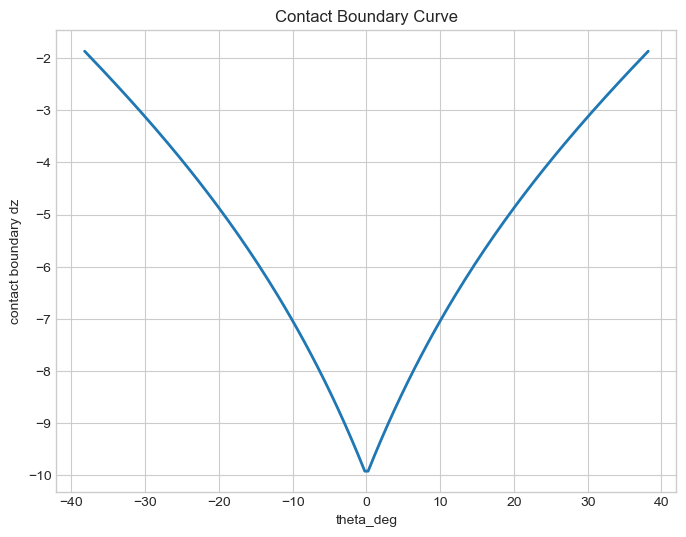

In [352]:
boundary = trace_contact_boundary(
    conf_ref=conf_1,
    theta_vals=theta_vals,
    dz_min=-12,
    dz_max=2,
    n_scan=500,
    dz_tol=1e-5,
)

print("Number of boundary hits:", len(boundary))
plot_contact_boundary(boundary)

In [353]:
hit = find_first_contact_dz_for_theta(
    conf_ref=conf_1,
    theta_deg=0,
    dz_min=-12,
    dz_max=2,
    n_scan=500,
    dz_tol=1e-5,
)

print(hit)

{'theta_deg': 0, 'candidate_dz': -9.99999853222069, 'candidate_conf': {y0B: 0, z0B: 0, y0L: -8, z0L: 10, y0R: 8, z0R: 10, y0T: 0, z0T: 20, y1B: 0.0, z1B: 1.4677793096495861e-06, y1L: -8.0, z1L: 10.00000146777931, y1R: 8.0, z1R: 10.00000146777931, y1T: 0.0, z1T: 20.00000146777931}, 'candidate_contact_value': 9.169144656409483e-07, 'contact_key': 'seg_1L_1B_cannot_cross_0L_signed_barrier', 'left_state': 'invalid_overlap', 'right_state': 'free'}


In [357]:
def classify_boundary_points(boundary, conf_ref):
    boundary_results = []

    for b in boundary:
        conf = b["candidate_conf"]
        jam_result = classify_jamming_state(conf, conf_ref)

        boundary_results.append({
            "theta_deg": b["theta_deg"],
            "dz": b["candidate_dz"],
            "contact_key": b["contact_key"],
            "contact_value": b["candidate_contact_value"],
            "jam_state": jam_result["state"],
            "jam_result": jam_result,
        })

    return boundary_results

In [358]:
boundary_results = classify_boundary_points(boundary, conf_1)

In [362]:
boundary_results

[{'theta_deg': -38.21608040201005,
  'dz': -1.865205508673597,
  'contact_key': 'seg_1L_1B_cannot_cross_0L_signed_barrier',
  'contact_value': 1.9901415341610505e-06,
  'jam_state': 'free',
  'jam_result': {'state': 'free',
   'base_contact_state': 'free',
   'n_contact_survivors': None,
   'n_free_survivors': None,
   'n_blocked': None,
   'contact_survivors': [],
   'free_survivors': [],
   'blocked': [],
   'theta_deg': None,
   'dz': None}},
 {'theta_deg': -37.76381909547739,
  'dz': -1.9319141212111721,
  'contact_key': 'seg_1L_1B_cannot_cross_0L_signed_barrier',
  'contact_value': -2.1087472255617573e-06,
  'jam_state': 'invalid_overlap',
  'jam_result': {'state': 'invalid_overlap',
   'base_contact_state': 'invalid_overlap',
   'n_contact_survivors': None,
   'n_free_survivors': None,
   'n_blocked': None,
   'contact_survivors': [],
   'free_survivors': [],
   'blocked': [],
   'theta_deg': None,
   'dz': None}},
 {'theta_deg': -37.311557788944725,
  'dz': -1.9988693206725947,


In [363]:
def plot_boundary_by_jam_state(boundary_results):
    theta = [b["theta_deg"] for b in boundary_results]
    dz = [b["dz"] for b in boundary_results]
    states = [b["jam_state"] for b in boundary_results]
    colors = [state_to_color(s) for s in states]

    # count occurrences
    counts = Counter(states)

    plt.figure(figsize=(8,6))
    plt.scatter(theta, dz, c=colors, s=20)

    plt.xlabel("theta_deg")
    plt.ylabel("contact boundary dz")
    plt.title("Contact Boundary Colored by Jamming State")
    plt.grid(True)

    # legend with counts
    legend_colors = {
        "invalid_overlap": "#264653",
        "jammed": "#2A9D8F",
        "semi-jammed": "#E9C46A",
        "contact_escape": "#F4A261",
        "free": "#E76F51",
    }

    for label, color in legend_colors.items():
        n = counts.get(label, 0)
        plt.scatter([], [], c=color, label=f"{label} (n={n})")

    plt.legend(loc="center left", bbox_to_anchor=(1, 0.5))
    plt.tight_layout()
    plt.show()

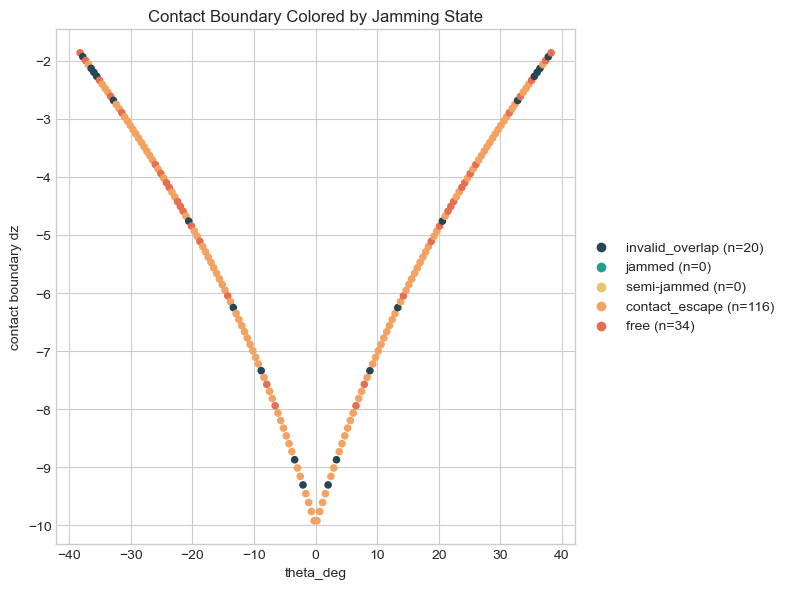

In [364]:
plot_boundary_by_jam_state(boundary_results)

In [ ]:
contact_mode_counts = Counter([b["contact_key"] for b in boundary_results])
print(contact_mode_counts)

Counter({'seg_1L_1B_cannot_cross_0L_signed_barrier': 85, 'seg_1R_1B_cannot_cross_0R_signed_barrier': 85})
